# Exposure Time Calculator

`slicersim.lazuli_etc`: a top level function to quickly get the expected exposure time.

## Any spectrum

Provide a spectrum with good spectral resolution. 

The input flux could be in physical units (“flambda“: erg/s/cm2/A) and/or you can manually set the desired flux amplitude in a given band (e.g. 20mag in "sdssr").

Lazuli's spectrograph covered 4000 A to 17_000 A. Your input spectrum should cover at least that too.

In [1]:
import numpy as np
import slicersim

In [2]:
# fake flat spectrum
lbda = np.arange(3_000, 20_000, 0.5) # every 0.5A
flux = np.ones( lbda.shape )

Say you want the exposure time needed to obtained an average signal to noise ratio of 20
between 7000 A and 8000 A. And you want this target to have 21 mag in the “sdssr“ band.

In [3]:
%%time
exptime, target = slicersim.lazuli_etc(lbda, flux, snr=20, 
                                       per_resolution=True,
                                       lbda_range=[7000, 8000], 
                                       mag=23, band="sdssr")

CPU times: user 1.73 s, sys: 132 ms, total: 1.86 s
Wall time: 1.86 s


In [4]:
print(f"{exptime=} seconds")

exptime=1064.08 seconds


## Access the realistic spectrum

In [5]:
lbda, flux_true, variance = target.get_spectrum(unit="flambda", incl_error=False)
flux = np.random.normal(loc=flux_true, scale=np.sqrt(variance))

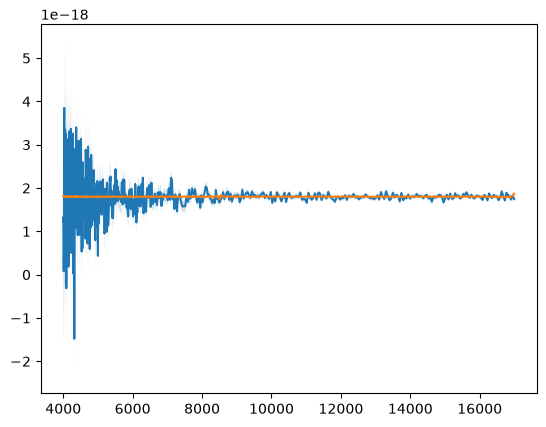

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(lbda, flux)
ax.plot(lbda, flux_true)
ax.fill_between(lbda, 
                flux+np.sqrt(variance), 
                flux-np.sqrt(variance), alpha=0.2)

## Type Ia Supernovae

Lazuli's spectrograph primary aims at targeting Type Ia Supernovae (SN Ia). 

There is a wrapper of the Lazuli object that enables you to get a realist SN Ia given its properties, such as the SALT stretch (x1), color (c) and redshift.

Say we want an average signal to noise of 15 in the rest-frame 4000A to 7000A

In [9]:
exptime, this_snia = slicersim.lazuli_sn_etc("salt", 
                                             redshift=1.2, c=0.1, x1=-0.5, 
                                             snr=15, per_resolution=True,
                                             lbda_range=[4000, 7000], 
                                             frame="rest")
exptime_h = exptime / 3600

In [10]:
print(f"{exptime_h=:.1f} hours")

exptime_h=2.4 hours


In [11]:
lbda, flux, variance = this_snia.get_spectrum(unit="flambda")

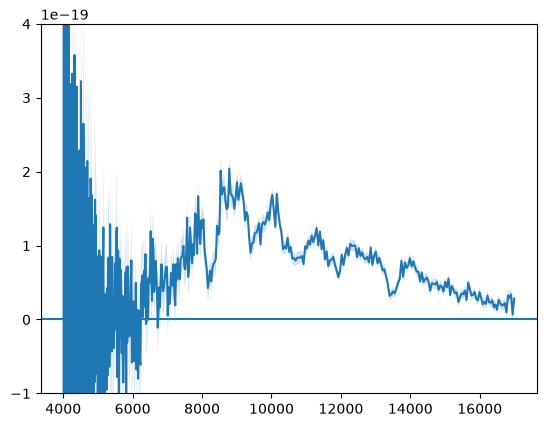

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(lbda, flux)
ax.fill_between(lbda, 
                flux+np.sqrt(variance), 
                flux-np.sqrt(variance), alpha=0.2)
ax.set_ylim(-0.1e-18, 0.4e-18)
ax.axhline(0)
